In [1]:
from ntk_utils import NTKHelper

In [2]:
# Network
from nets import net_dict
import torch
from torch import nn
import numpy as np

net = nn.Sequential(*(net_dict['resnet18-imagenet']().getNets(
    [3, 224, 224],
    [1000,],
)))
net.eval()
net.cuda()

conv1_type:imagenet
no_maxpool:False


Sequential(
  (0): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU()
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (r

In [3]:
ntk_helper = NTKHelper(net, torch.LongTensor(np.random.choice(1000, 10)))

In [4]:
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms

np.random.seed(42)

from openood.datasets.imglist_dataset import ImglistDataset
from openood.evaluation_api.preprocessor import get_default_preprocessor

prepro = get_default_preprocessor('imagenet')

id_dataset = ImglistDataset(
    name = 'test',
    imglist_pth = '/home/zhang/RP_ML/ttuq-openood/data/benchmark_imglist/imagenet/val_imagenet.txt',
    data_dir = '/home/zhang/RP_ML/ttuq-openood/data/images_largescale',
    num_classes = 1000,
    preprocessor = prepro,
    data_aux_preprocessor = prepro
)

N_train = 256
X_dataset = torch.utils.data.Subset(id_dataset, np.random.choice(len(id_dataset), N_train))

In [5]:
from torch.utils.data import DataLoader

X = DataLoader(X_dataset, batch_size = 4, shuffle = False)

_Oxx_diag = ntk_helper.compute_ntk(X, X, batch_mode = '1to1', x1_map = lambda b : b['data'], x2_map = lambda b : b['data']).detach().cpu().numpy()
np.save("IDxx.npy", _Oxx_diag)

In [6]:
from openood.datasets.imglist_dataset import ImglistDataset
from openood.evaluation_api.preprocessor import get_default_preprocessor
import os

ood_datasets = {
    "ImageNet": "benchmark_imglist/imagenet/test_imagenet.txt",
    "ImageNet-C": "benchmark_imglist/imagenet/test_imagenet_c.txt",
    "ImageNet-R": "benchmark_imglist/imagenet/test_imagenet_r.txt",
    "ssb_hard": "benchmark_imglist/imagenet/test_ssb_hard.txt",
    "iNaturalList": "benchmark_imglist/imagenet/test_inaturalist.txt",
    "Textures": "benchmark_imglist/imagenet/test_textures.txt",
}

_Ozxs = {}

In [7]:
N_test = 128
for key in ood_datasets:
    print(key)
    ood_dataset = ImglistDataset(
        name = 'test',
        imglist_pth = os.path.join("/home/zhang/RP_ML/ttuq-openood/data/", ood_datasets[key]),
        data_dir = "/home/zhang/RP_ML/ttuq-openood/data/images_largescale" if key != "Textures" else "/home/zhang/RP_ML/ttuq-openood/data/images_classic",
        num_classes = 1000,
        preprocessor = prepro,
        data_aux_preprocessor = prepro
    )
    Z_dataset = torch.utils.data.Subset(ood_dataset, np.random.choice(len(ood_dataset), N_test))
    Z = DataLoader(Z_dataset, batch_size = 4, shuffle = False)
    _Ozxs[key] = ntk_helper.compute_ntk(Z, X, mode = 'full', x1_map = lambda b : b['data'], x2_map = lambda b : b['data']).detach().cpu().numpy()
    np.save("%s.npy" % key, _Ozxs[key])

ImageNet
ImageNet-C
ImageNet-R
ssb_hard
iNaturalList
Textures


In [8]:
# _Oxx_diag = np.load("IDxx.npy")
# for key in ood_datasets:
#     _Ozxs[key] = np.load("%s.npy" % key)

In [9]:
def visualize(Ozx, Oxx):
    # lhs = (Ozx - torch.abs(Ozx).mean(dim = 0, keepdims = True)).max(dim = 1)[0].detach().cpu().numpy()
    # rhs = (Oxx - Oxx.mean()).max().item()
    # lhs = (2 * Ozx - 2 * np.abs(Ozx).mean(axis = 0, keepdims = True)).max(axis = 1)
    # rhs = (Oxx - Oxx.mean()).min().item()
    print(Ozx.shape)
    print(Oxx.shape)
    lhs = (Oxx[None, :] - 2 * np.trace(Ozx, axis1 = -1, axis2 = -2)).min(axis = 1)
    rhs = (Oxx.mean() - 2 * np.linalg.norm(Ozx, 'fro', axis = (-1, -2)).mean(axis = 1, keepdims = True))
    # rhs = (Oxx[None, :] - 2 * Ozx).mean(dim = 1)
    # print(Oxx.mean())
    # print(Oxx)
    return lhs, rhs

ls = {k: visualize(_Ozxs[k], _Oxx_diag)[0] for k in _Ozxs}
rs = {k: visualize(_Ozxs[k], _Oxx_diag)[1] for k in _Ozxs}
# r = visualize(_Ozxs["ImageNet"], _Oxx_diag)[1]
# print(ls)
# print(rs)

(128, 256, 10, 10)
(256,)
(128, 256, 10, 10)
(256,)
(128, 256, 10, 10)
(256,)
(128, 256, 10, 10)
(256,)
(128, 256, 10, 10)
(256,)
(128, 256, 10, 10)
(256,)
(128, 256, 10, 10)
(256,)
(128, 256, 10, 10)
(256,)
(128, 256, 10, 10)
(256,)
(128, 256, 10, 10)
(256,)
(128, 256, 10, 10)
(256,)
(128, 256, 10, 10)
(256,)


(128,)
(128, 1)
(128,)
(128, 1)
(128,)
(128, 1)
(128,)
(128, 1)
(128,)
(128, 1)
(128,)
(128, 1)


<Figure size 210x150 with 0 Axes>

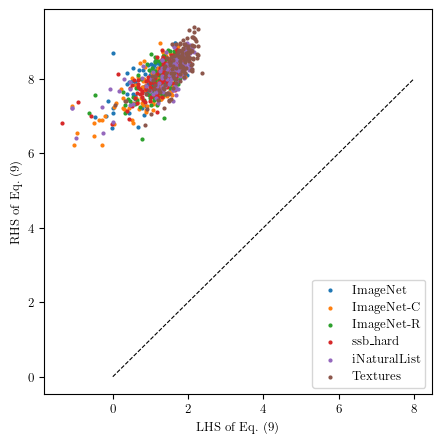

In [14]:
import matplotlib.pyplot as plt

plt.style.use('./aaai25.mplstyle')
plt.tight_layout()

fig, ax = plt.subplots(figsize = (5, 5))

# previous_files = {
#     "imagenet": "imagenet.npy",
#     # "imagenet-blur2": "imagenet-blur2.npy",
#     "imagenet-blur6": "imagenet-blur6.npy",
# }

# plt.scatter(np.random.normal(loc = 0.0, scale = 0.1, size = l.shape), l, s = 4)
# plt.boxplot(l)

# l_f = [np.load(previous_files[f]) for f in previous_files]
# plt.boxplot([l, *l_f], labels = ['l', *previous_files.keys()])

# l_f = [np.load(previous_files[f]) for f in previous_files]
# plt.boxplot(l_f, labels = previous_files.keys())

# l_f = [ls[l] for l in ls]
# plt.boxplot(l_f, flierprops={'marker': 'o', 'markersize': 3})
# plt.xticks([])

for l in ls:
    print(ls[l].shape)
    print(rs[l].shape)
    plt.scatter(ls[l], rs[l], label = l, s = 4)

plt.plot([0, 8], [0, 8], '--k', linewidth = 0.8)
plt.legend(loc='lower right')

# ax.text(.05,.83,'\\textbf{d)} RHS=$-6.24$',
#         horizontalalignment='left',
#         transform=ax.transAxes)
# ax.set_xlabel('Dataset ID')
# ax.set_ylabel('LHS of Eq.~(8)')

ax.set_xlabel('LHS of Eq.~(9)')
ax.set_ylabel('RHS of Eq.~(9)')

# a = plt.xlim()
# plt.hlines(r, -10, len(ls) + 10)
# plt.xlim(a)

plt.savefig("Eq9-visualization.pdf", format="pdf", bbox_inches = 'tight')

<Figure size 210x150 with 0 Axes>

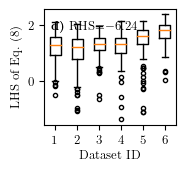

In [11]:
import matplotlib.pyplot as plt

plt.style.use('./aaai25.mplstyle')
plt.tight_layout()

fig, ax = plt.subplots(figsize = (1.7, 1.5))

# previous_files = {
#     "imagenet": "imagenet.npy",
#     # "imagenet-blur2": "imagenet-blur2.npy",
#     "imagenet-blur6": "imagenet-blur6.npy",
# }

# plt.scatter(np.random.normal(loc = 0.0, scale = 0.1, size = l.shape), l, s = 4)
# plt.boxplot(l)

# l_f = [np.load(previous_files[f]) for f in previous_files]
# plt.boxplot([l, *l_f], labels = ['l', *previous_files.keys()])

# l_f = [np.load(previous_files[f]) for f in previous_files]
# plt.boxplot(l_f, labels = previous_files.keys())

l_f = [ls[l] for l in ls]
plt.boxplot(l_f, flierprops={'marker': 'o', 'markersize': 3})
# plt.xticks([])

ax.text(.05,.83,'\\textbf{d)} RHS=$-6.24$',
        horizontalalignment='left',
        transform=ax.transAxes)
ax.set_xlabel('Dataset ID')
ax.set_ylabel('LHS of Eq.~(8)')

# for i, f in enumerate(previous_files):
#     l_f = np.load(previous_files[f])
#     plt.boxplot(l_f)
#     # plt.scatter(np.random.normal(loc = i + 1, scale = 0.1, size = l_f.shape), l_f, s = 4)

a = plt.xlim()
# plt.hlines(r, -10, len(ls) + 10)
plt.xlim(a)

plt.savefig("Lemma-condition.pdf", format="pdf", bbox_inches = 'tight')

In [12]:
# np.save("imagenet.npy", l)
# np.save("imagenet-rhs.npy", r)

In [13]:
print(_Ozxs.keys())
# del _Ozxs['Textures']

dict_keys(['ImageNet', 'ImageNet-C', 'ImageNet-R', 'ssb_hard', 'iNaturalList', 'Textures'])
